In [ ]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.line_heuristics.harmony_search import HarmonyLineSearch
from converters.tile.bin_1d import make_1d_bin_palette

from tests.experimental.grayscale.test_loop import Params, test_loop

FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
ALL_SYMBOLS = get_asciis()
SYMBOLS = [s[len(s) // 2] for s in make_1d_bin_palette(ALL_SYMBOLS, FONT, 5)[0]]
MAX_WIDTH = 40
MAX_HEIGHT = 12
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:5]]

def make_converter(params: Params):
    return HarmonyLineSearch(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        pop_count=20,
        generations=200,
        **params.converter_args)

Min: -0.0083 | Max: 0.0656 | Mean: 0.0387 | Std: 0.0263
Min: -0.0065 | Max: 0.0891 | Mean: 0.0576 | Std: 0.0339
Min: 0.0233 | Max: 0.1026 | Mean: 0.0749 | Std: 0.0283
Min: 0.0478 | Max: 0.1144 | Mean: 0.0911 | Std: 0.0242
Min: 0.0391 | Max: 0.1227 | Mean: 0.0924 | Std: 0.0293


C:\Users\wojte\AppData\Local\Temp\ipykernel_15492\2130949569.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


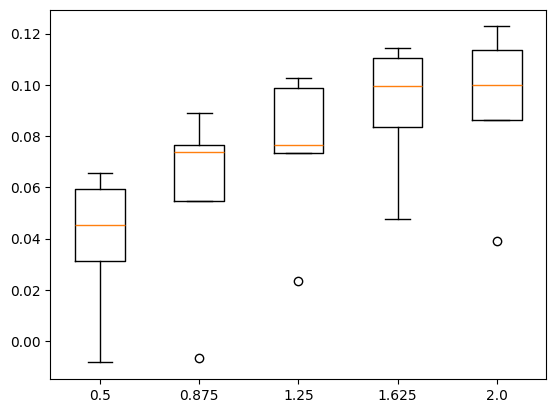

In [2]:
# contrast

params_space = [
    {'contrast': c, 'scale_factor': 0.3} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [ ]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = HarmonyLineSearch(symbols=SYMBOLS,
                                    font=FONT,
                                    pop_count=20,
                                    generations=200)

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    font_height_px = FONT_SIZE * 1.333
    font_width_px = FONT_SIZE * 0.5
    scale_h = MAX_HEIGHT * font_height_px / img.height
    scale_w = MAX_WIDTH * font_width_px / img.width
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    results.append(converter.process_image(img))

print_gallery(results, 1)

----------------------------------------------
 | ==KwwKwww==ww===www==wKwwI=K:w:wIIIIK::I | 
 | :::::::::::K:KK=KK=::::::=:=:K=::::::::: | 
 | w==w:K:::wK:w::w:::::::::::::::::::::::: | 
 | ::I=KK::KKIKwwKK:KIKIIKIIwK:ww=I=K:=K=I= | 
 | :KKIwwI:II=IK:wwwKIKKKww:I:=II=w=w:IKKKK | 
 | IKI=I=IKwKII=w:IwKK=wKKII:=::=wwIwKK:=I= | 
 | KKwKKKKwK==:K=K=:=KKKIKI=wIKKwK=KK==KIwK | 
 | KKwKKIKKwK:=w==:=:KKwwKKKwKIKwKKK=Kw:IKK | 
 | wKIw==wI:KKKw:w:=IKww::KIIIIKKI=wKKI:I=I | 
 | KIKKKKKKKKKKKKIIK:KwKK=KIKKKK=K:=w==Iww= | 
 | =w=w:IKK::KK=w==Kww=wIw=wKKIKK:KwwI:I=:K | 
 | KIKKKww=I:IIw=w=KKww==KKIK:=IK=KI:K=:KwK | 
 | II=:IwwK=:I=wIK=:wK=KIK=wK=KwIK=IKwI:IwI | 
----------------------------------------------
 | KKKK=IIKKwwK==KK:I=:=IKIKKKKwKwwwK:KwKII | 
 | IK:==K:==KIK:KIIKIKKKK=:KK==IKIK==wwKIK: | 
 | K:wKw::wKKKI=KKwIIwIw:===K=K=KwK=wwKI=w= | 
 | =::::wwKIIwKIKKK==II====Kw:KK=:KK=KKK:w: | 
 | ::=K:=KwKKww=wKKKw=:I=:Iw=KKIwK=KK:KwK=I | 
 | K=IIKKKKKKwK=::w:::::wI==KIw=IKKKKwKKw:= | 
 | K:KwwwK=KK